In [56]:
import pandas as pd
import numpy as np
import math
import scipy.stats as stats
from pathlib import Path
from results.topology_results import TopologyResults

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [57]:
PATH_TO_RESULTS_PARENT_FOLDER = Path(
     "../../results/20260206/batch_20260206_21-45-57"
    #"../../results/batch_20260206_21-45-57"
).resolve()

# Find all topology folders
TOPOLOGY_FOLDERS = sorted(
    [d for d in PATH_TO_RESULTS_PARENT_FOLDER.iterdir() if d.is_dir()]
)
print(
    f"Found {len(TOPOLOGY_FOLDERS)} topologies to analyze: {[t.name for t in TOPOLOGY_FOLDERS]}"
)

# Metrics configuration for statistics printing
METRICS_CONFIG = [
    ("pdr", "PDR [95% CI]"),
    ("latency_ms", "Latency-ms [95% CI]"),
    ("hop_stretch", "Hop Stretch [95% CI]"),
]

Found 5 topologies to analyze: ['grid_20N', 'linear_20N', 'random_20N', 'ring_20N', 'star_20N']


In [58]:
# --- HELPER
def compute_ci(data, confidence=0.95):
    """Computes Mean and 95% CI Margin."""
    a = 1.0 * np.array(data)
    n = len(a)
    if n < 2: return np.mean(a), np.mean(a), np.mean(a), 0.0
    m = np.mean(a)
    se = stats.sem(a) # sem is std_dev/sqrt(n)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h, h  # Mean, Lower, Upper, Margin

def compute_95ci_bootsrap(data):
    """Returns Mean and 95% CI with Bootstrap."""
    a = 1.0 * np.array(data) #convert to numpy float
    mean = np.mean(a)
    means = np.zeros(1000)
    for i in range(999):
        boot_sample = np.random.choice(a, size=len(a), replace=True) #draw from data with replacement
        means[i] = np.mean(boot_sample)

    #sort
    means = np.sort(means)
    ci_low = means[24]
    ci_high = means[974]
    
    return mean, ci_low, ci_high

In [59]:
# DATA PROCESSING
all_results_list = []

for topo_folder in TOPOLOGY_FOLDERS:
    topo_name = topo_folder.name
    print(f"Processing Topology: {topo_name}...")

    # LOAD RESULTS (PDR, LATENCY)
    topo_results = TopologyResults.from_folder(topo_folder)
    data_list = []

    for channel_res in topo_results.channels:
        for rep in channel_res.repetitions:
            # PDR data may be missing if the channel has no connectivity
            pdr_val = (
                rep.pdr_df.delivered.mean()
                if rep.pdr_df is not None and not rep.pdr_df.empty
                else 0
            )

            # Latency also might be None or empty
            latency_val = None
            if rep.latency_df is not None and not rep.latency_df.empty:
                latency_val = rep.latency_df.latency.mean()

            data_list.append(
                {
                    "topology": topo_name,
                    "channel_id": channel_res.channel_type,
                    "rep_id": rep.id,
                    "pdr": pdr_val,
                    "latency": latency_val,
                }
            )

    # Create df for standard results
    df_std = pd.DataFrame(data_list)

    # LOAD HOP STRETCH RESULTS FROM EXTERNAL CSV
    hs_topo_folder = (
        PATH_TO_RESULTS_PARENT_FOLDER.parent
        / "processed_results"
        / PATH_TO_RESULTS_PARENT_FOLDER.name
        / "hop_stretch"
        / topo_name
    )

    hs_ch_dfs = []

    # Iterate assuming the folder exists and has content
    if hs_topo_folder.exists():
        for channel_dir in hs_topo_folder.iterdir():
            if not channel_dir.is_dir():
                continue

            hs_file = channel_dir / "hop_stretch.csv"

            try:
                hs_ch_df = pd.read_csv(hs_file)
                # Group hop stretches by repetition ID. Aggregate mean per repetition.
                hs_ch_df = (
                    hs_ch_df.groupby("id")["hop_stretch"]
                    .mean()
                    .reset_index()
                    .rename(columns={"id": "rep_id"})
                )
                hs_ch_df["channel_id"] = channel_dir.name
                hs_ch_dfs.append(hs_ch_df)
            except Exception as e:
                print(f"  [WARNING] Error reading HS file {hs_file}: {e}")

    # MERGE AND PREPROCESS
    if hs_ch_dfs:
        df_hs = pd.concat(hs_ch_dfs, ignore_index=True)
        topo_df = df_std.merge(df_hs, on=["channel_id", "rep_id"], how="left")
    else:
        print(f"  [INFO] No Hop Stretch data found for {topo_name}")
        topo_df = df_std
        topo_df["hop_stretch"] = np.nan

    # Calculate Latency in milliseconds
    topo_df["latency_ms"] = topo_df["latency"] * 1000

    # Add the complete dataframe for this topology to the global list
    all_results_list.append(topo_df)

# --- FINAL AGGREGATION ---
all_results_df = pd.concat(all_results_list, ignore_index=True)

Processing Topology: grid_20N...
Processing Topology: linear_20N...
Processing Topology: random_20N...
Processing Topology: ring_20N...
Processing Topology: star_20N...
  [WARNING] Error reading HS file /home/damole/Documents/develop/SPE-project/results/20260206/processed_results/batch_20260206_21-45-57/hop_stretch/star_20N/stable_high_pl/hop_stretch.csv: 'Column not found: hop_stretch'


In [60]:
def average_antithetic_pairs(
    df: pd.DataFrame,
    metrics: list[str] = ["pdr", "latency", "latency_ms", "hop_stretch"],
) -> pd.DataFrame:
    mask_antithetic = df["rep_id"].str.contains("antithetic", na=False)

    antithetic_df = df[mask_antithetic]
    non_antithetic_df = df[~mask_antithetic]

    antithetic_df["base_rep_id"] = antithetic_df["rep_id"].str.replace(
        "_antithetic", "", regex=False
    )

    merged_df = pd.merge(
        non_antithetic_df,
        antithetic_df,
        left_on=["topology", "channel_id", "rep_id"],
        right_on=["topology", "channel_id", "base_rep_id"],
        how="inner",
        suffixes=("", "_antithetic"),
    )

    for metric in metrics:
        if metric in merged_df.columns and f"{metric}_antithetic" in merged_df.columns:
            merged_df[metric] = merged_df[[metric, f"{metric}_antithetic"]].mean(axis=1)
        if f"{metric}_antithetic" in merged_df.columns:
            merged_df.drop(columns=[f"{metric}_antithetic"], inplace=True)

    merged_df.drop(columns=["base_rep_id", "rep_id_antithetic"], inplace=True)

    return merged_df

In [61]:
all_results_df = average_antithetic_pairs(all_results_df)

In [62]:
all_stats_list = []

for topo_name in all_results_df["topology"].unique():
    topo_df = all_results_df[all_results_df["topology"] == topo_name]
    # COMPUTE STATISTICS
    unique_channels = topo_df["channel_id"].unique()

    for channel in unique_channels:
        subset = topo_df[topo_df["channel_id"] == channel]
        row = {"Topology": topo_name, "Channel": channel}

        for col_name, display_name in METRICS_CONFIG:
            data = subset[col_name].dropna()

            if len(data) > 1:
                mean, lower, upper= compute_95ci_bootsrap(data)
                row[f"{col_name}_mean"] = mean
                #row[f"{col_name}_margin"] = margin
                row[display_name] = f"{mean:.3f}, [{lower:.3f}, {upper:.3f}]"
            else:
                row[f"{col_name}_mean"] = np.nan
                row[f"{col_name}_margin"] = 0
                row[display_name] = "N/A"

        all_stats_list.append(row)


all_stats_df = pd.DataFrame(all_stats_list)

In [63]:
print("="*100)
print(f"GLOBAL PROCESSING COMPLETE. Total records processed: {len(all_results_df)}")
print("="*100 + "\n")

# Print Summary Table
print("="*100)
print(f"STATISTICS SUMMARY")
print("="*100)
display_cols = ["Topology", "Channel"] + [m[1] for m in METRICS_CONFIG]
print(all_stats_df[display_cols].to_string(index=False))

GLOBAL PROCESSING COMPLETE. Total records processed: 1500

STATISTICS SUMMARY
  Topology        Channel          PDR [95% CI]      Latency-ms [95% CI]  Hop Stretch [95% CI]
  grid_20N          lossy 0.856, [0.848, 0.864] 11.543, [11.440, 11.646] 2.729, [2.705, 2.749]
  grid_20N  stable_mid_pl 0.879, [0.873, 0.887] 11.048, [10.970, 11.128] 2.808, [2.791, 2.824]
  grid_20N stable_high_pl 0.671, [0.663, 0.679] 22.470, [22.321, 22.614] 2.109, [2.098, 2.121]
  grid_20N       unstable 0.610, [0.602, 0.618] 22.590, [22.303, 22.858] 1.982, [1.968, 1.998]
  grid_20N         stable 0.960, [0.957, 0.962]    6.728, [6.698, 6.757] 2.305, [2.289, 2.320]
  grid_20N          ideal 0.965, [0.963, 0.968]    6.669, [6.642, 6.697] 2.250, [2.236, 2.264]
linear_20N          lossy 0.846, [0.839, 0.854] 14.101, [13.931, 14.268] 2.546, [2.526, 2.565]
linear_20N  stable_mid_pl 0.877, [0.870, 0.884] 13.502, [13.381, 13.618] 2.559, [2.544, 2.575]
linear_20N stable_high_pl 0.784, [0.777, 0.791] 24.448, [24.259, 24

In [64]:
# PLOT SETUP
sns.set_theme(style="whitegrid", palette="bright")

# Grid Size
num_topos = len(TOPOLOGY_FOLDERS)
cols = 2
rows = math.ceil(num_topos / cols)

# SETTINGS

channel_order = [
    "ideal", 
    "stable", 
    "stable_mid_pl", 
    "stable_high_pl", 
    "lossy", 
    "unstable"
]


global_channels = [ch for ch in channel_order
                   if ch in all_results_df["channel_id"].unique()] # set channel order for all plots

global_palette = sns.color_palette(
    "bright", n_colors=len(global_channels)
)  # same color for all plot
global_color_map = dict(zip(global_channels, global_palette))

In [65]:
def plot_violin(metric_col, title_prefix, ylabel, ylim=None):

    fig, axes = plt.subplots(
        rows, cols, figsize=(14, 6 * rows), constrained_layout=True
    )
    axes_flat = axes.flatten() if num_topos > 1 else [axes]

    # Iterate over topologies
    for i, topo_folder in enumerate(TOPOLOGY_FOLDERS):
        topo_name = topo_folder.name
        ax = axes_flat[i]

        # Filter data per topology
        topo_data = all_results_df[all_results_df["topology"] == topo_name]

        # Skip if empty
        if topo_data.empty or topo_data[metric_col].dropna().empty:
            ax.text(0.5, 0.5, "No Data", ha="center", va="center")
            ax.set_title(f"{topo_name}")
            continue

        # VIOLIN PLOT
        sns.violinplot(
            data=topo_data,
            x="channel_id",
            y=metric_col,
            order=global_channels,  # Fixed order
            palette=global_color_map,
            ax=ax,
            inner=None,
            linewidth=1,
            alpha=0.6,
            cut=0 if metric_col == "pdr" else 2,  # Cut 0 for PDR avoids artifacts > 1.0
        )

        # POINT PLOT (Mean + 95% CI)
        # overlay this on the violin
        sns.pointplot(
            data=topo_data,
            x="channel_id",
            y=metric_col,
            order=global_channels,
            ax=ax,
            estimator="mean",  # plot mean estimate
            errorbar=("ci", 95),  # computes CI with bootstrap
            color="darkblue",
            markers="_",
            capsize=0.1,
            join=False,
            err_kws={"color": "black", "linewidth": 2},
        )

        # Format labels
        ax.set_title(f"{topo_name}", fontsize=14)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=45)

        # set limits for plots
        if ylim:
            # if metric_col == "hop_stretch":
            #     max_val = topo_data[metric_col].max()
            #     upper = max_val * 1.15 if not pd.isna(max_val) else 2.0
            #     ax.set_ylim(ylim[0], upper)
            # else:
            #     ax.set_ylim(ylim)
            ax.set_ylim(ylim)

        ax.minorticks_on()
        ax.grid(True, axis="y", alpha=0.5)
        ax.grid(True, axis="y", which="minor", alpha=0.3)

    # There are some subpllots that are not used
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{title_prefix} (Mean with 95% CI) per Topology", fontsize=18)

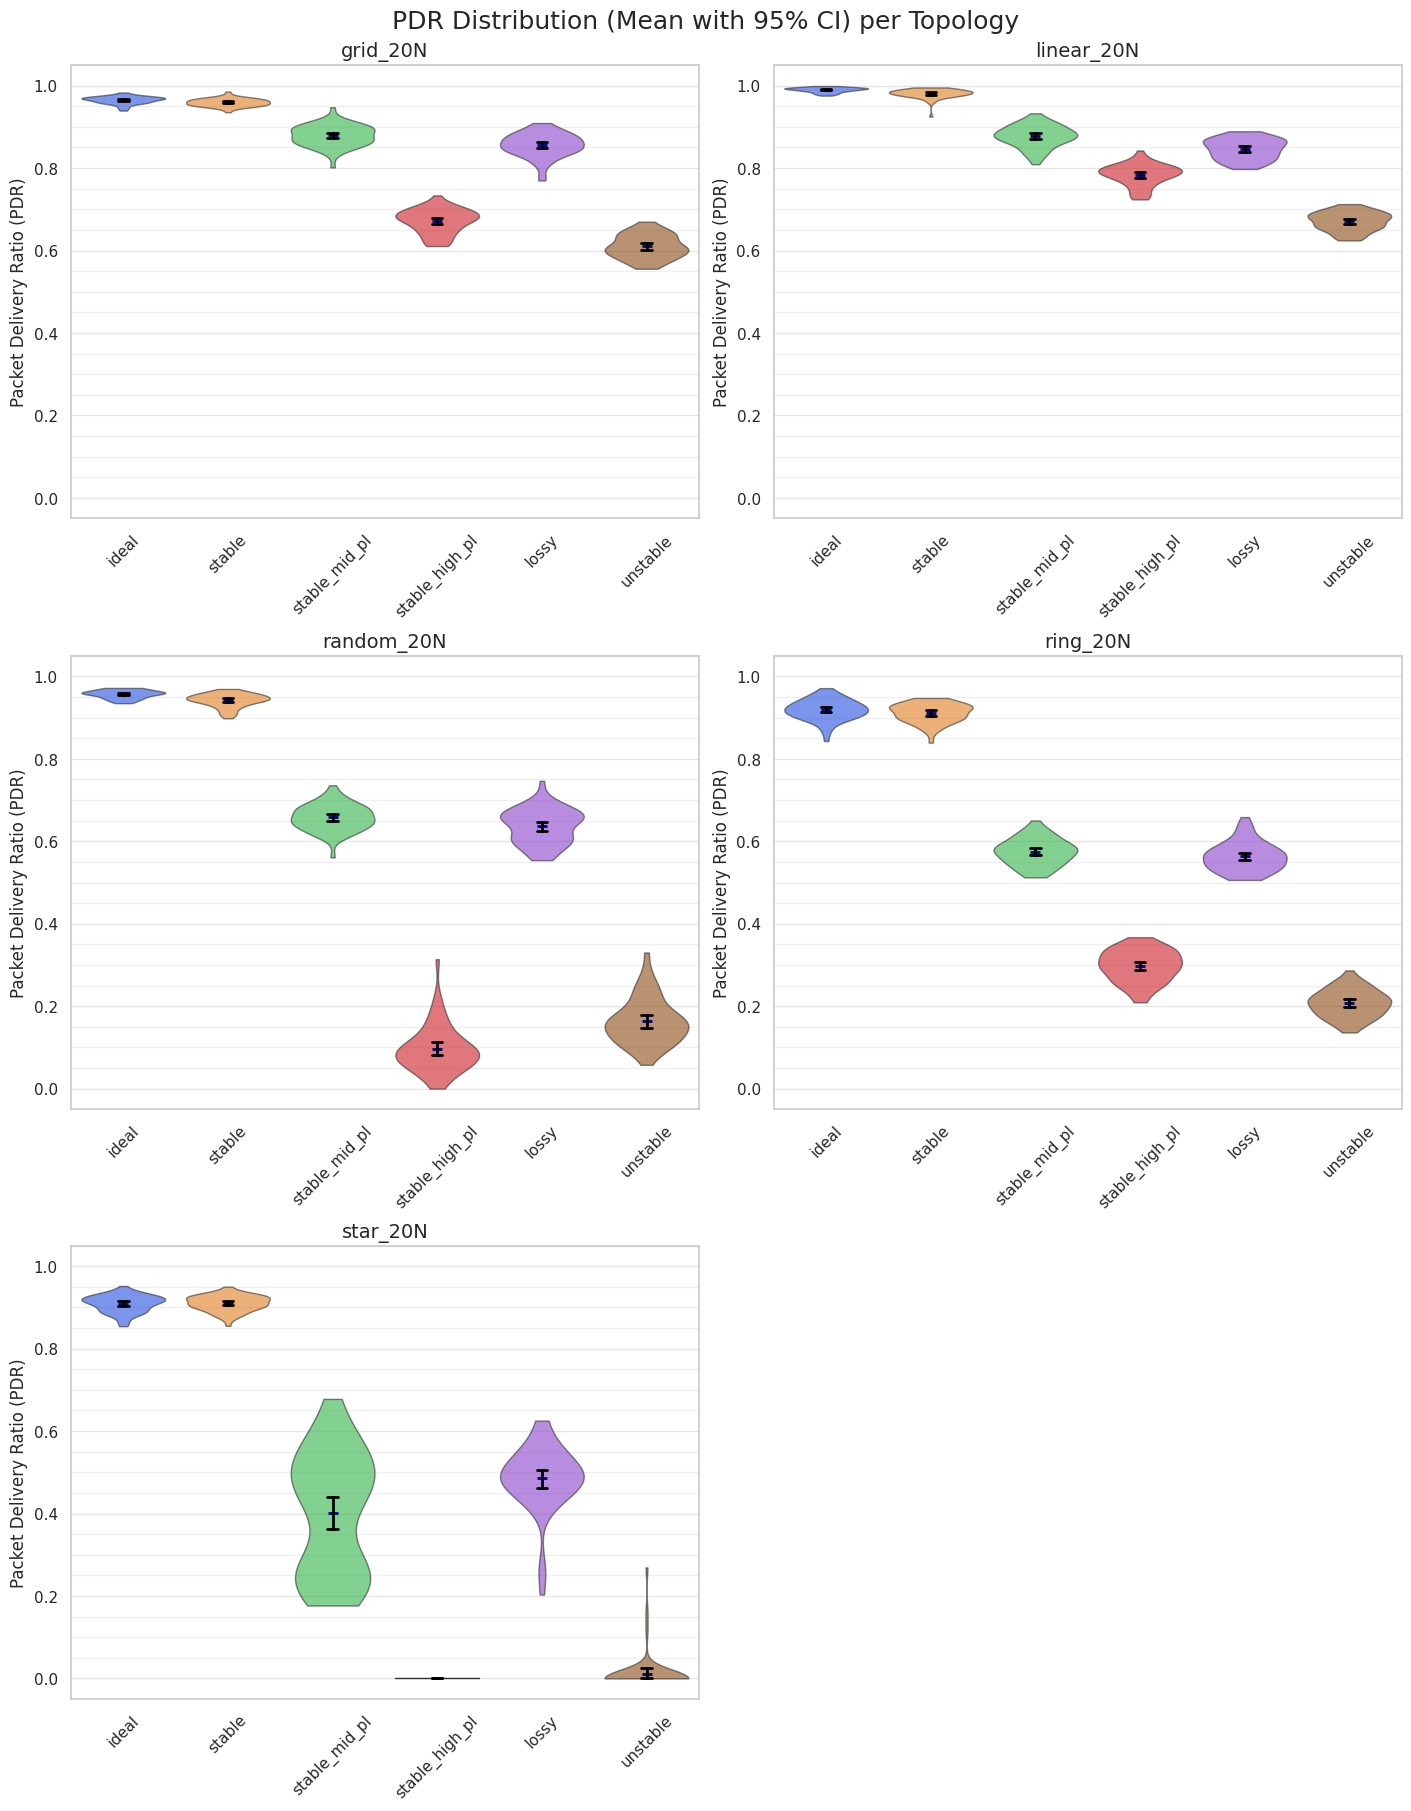

In [66]:
# ==============================================================================
# PLOT PDR
# ==============================================================================
plot_violin(
    metric_col="pdr", 
    title_prefix="PDR Distribution", 
    ylabel="Packet Delivery Ratio (PDR)", 
    ylim=(-0.05, 1.05) # PDR is bounded 0-1
)

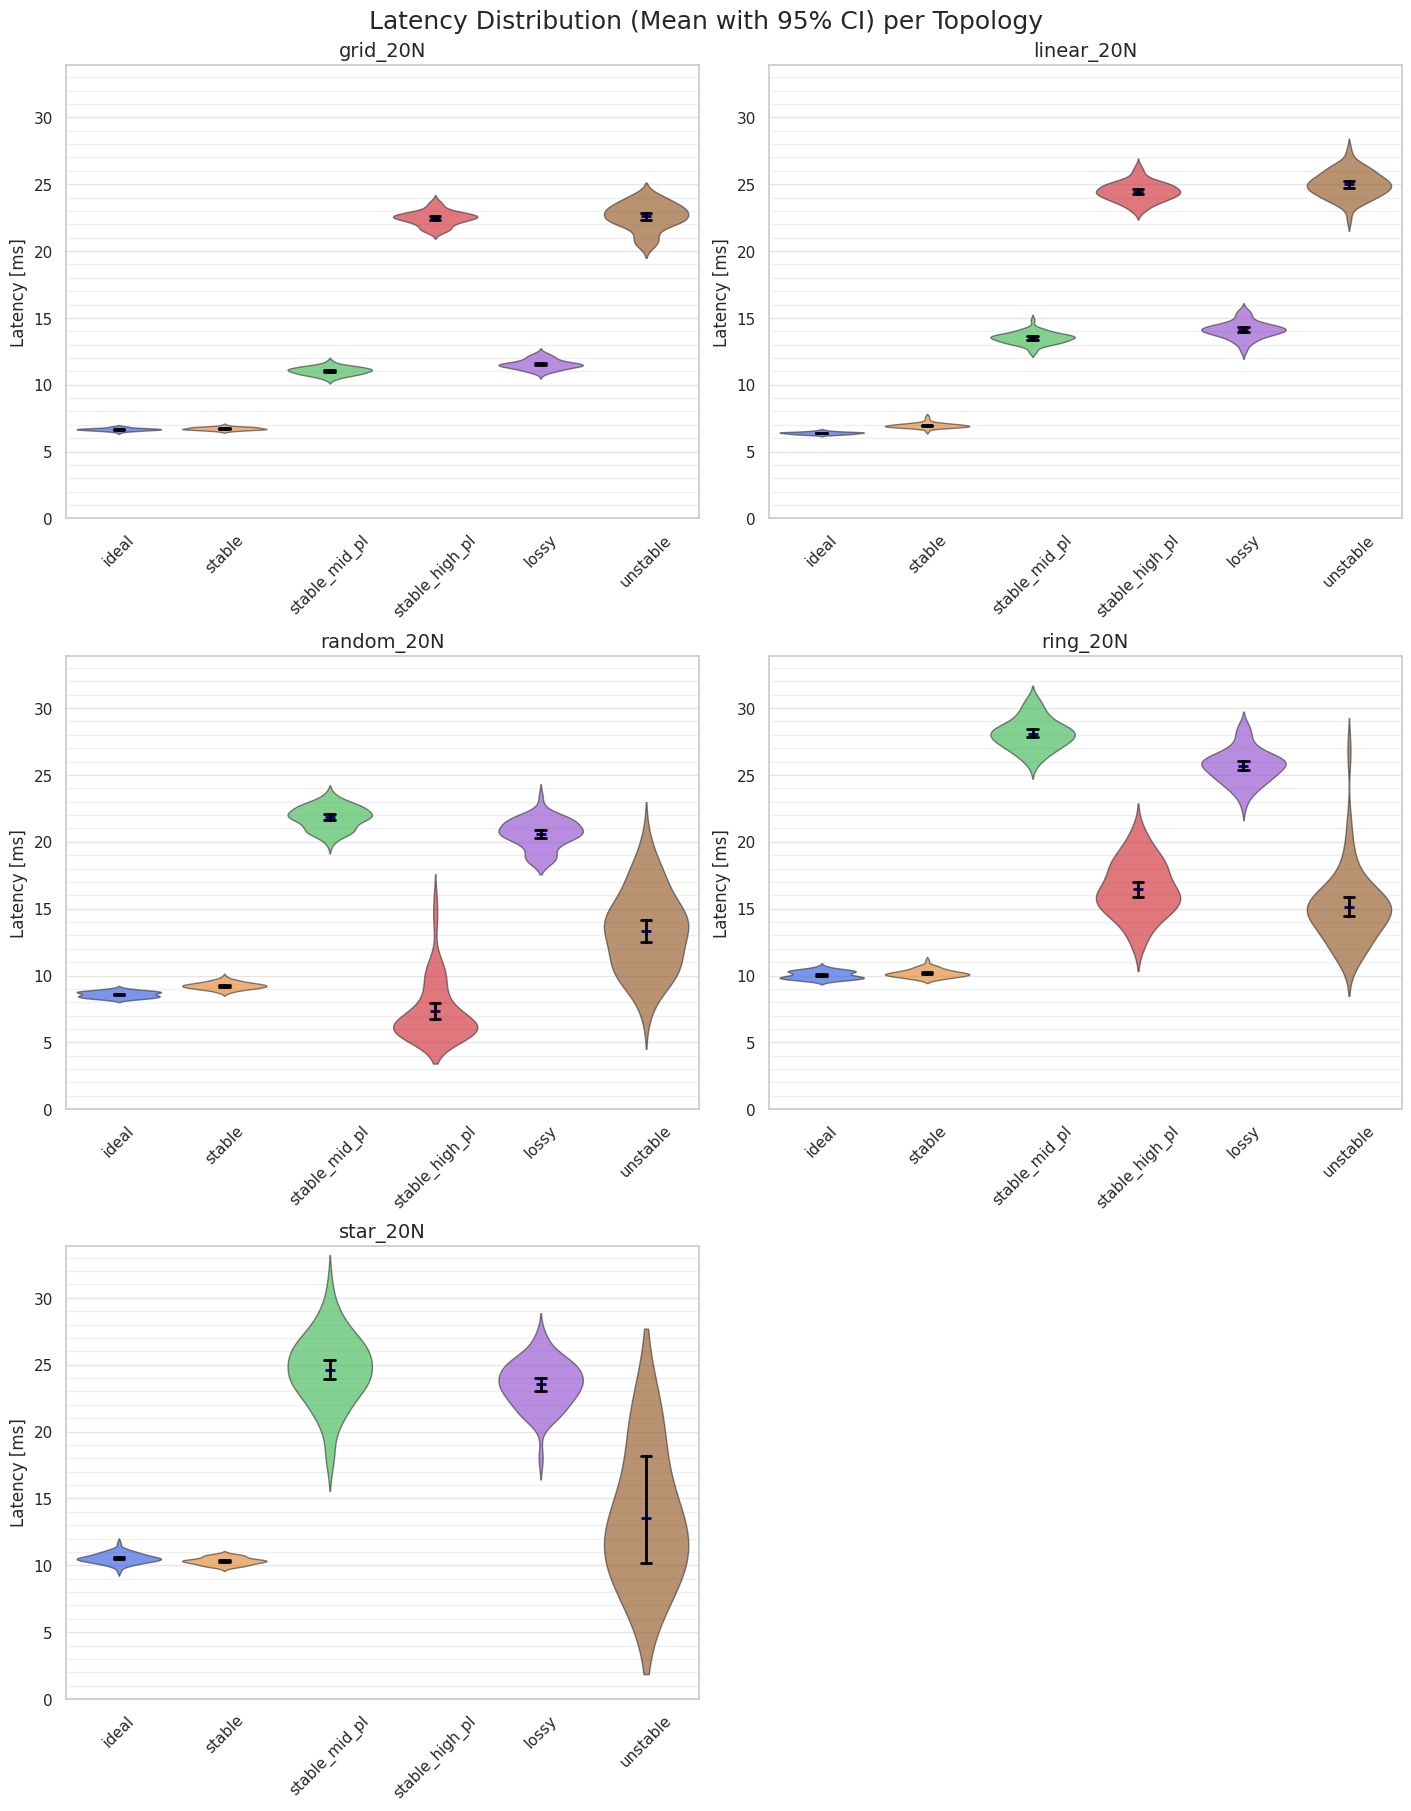

In [67]:
# ==============================================================================
# PLOT LATENCY
# ==============================================================================
plot_violin(
    metric_col="latency_ms", 
    title_prefix="Latency Distribution", 
    ylabel="Latency [ms]", 
    # ylim=None
    ylim=(0, all_results_df["latency_ms"].max() * 1.1)
)

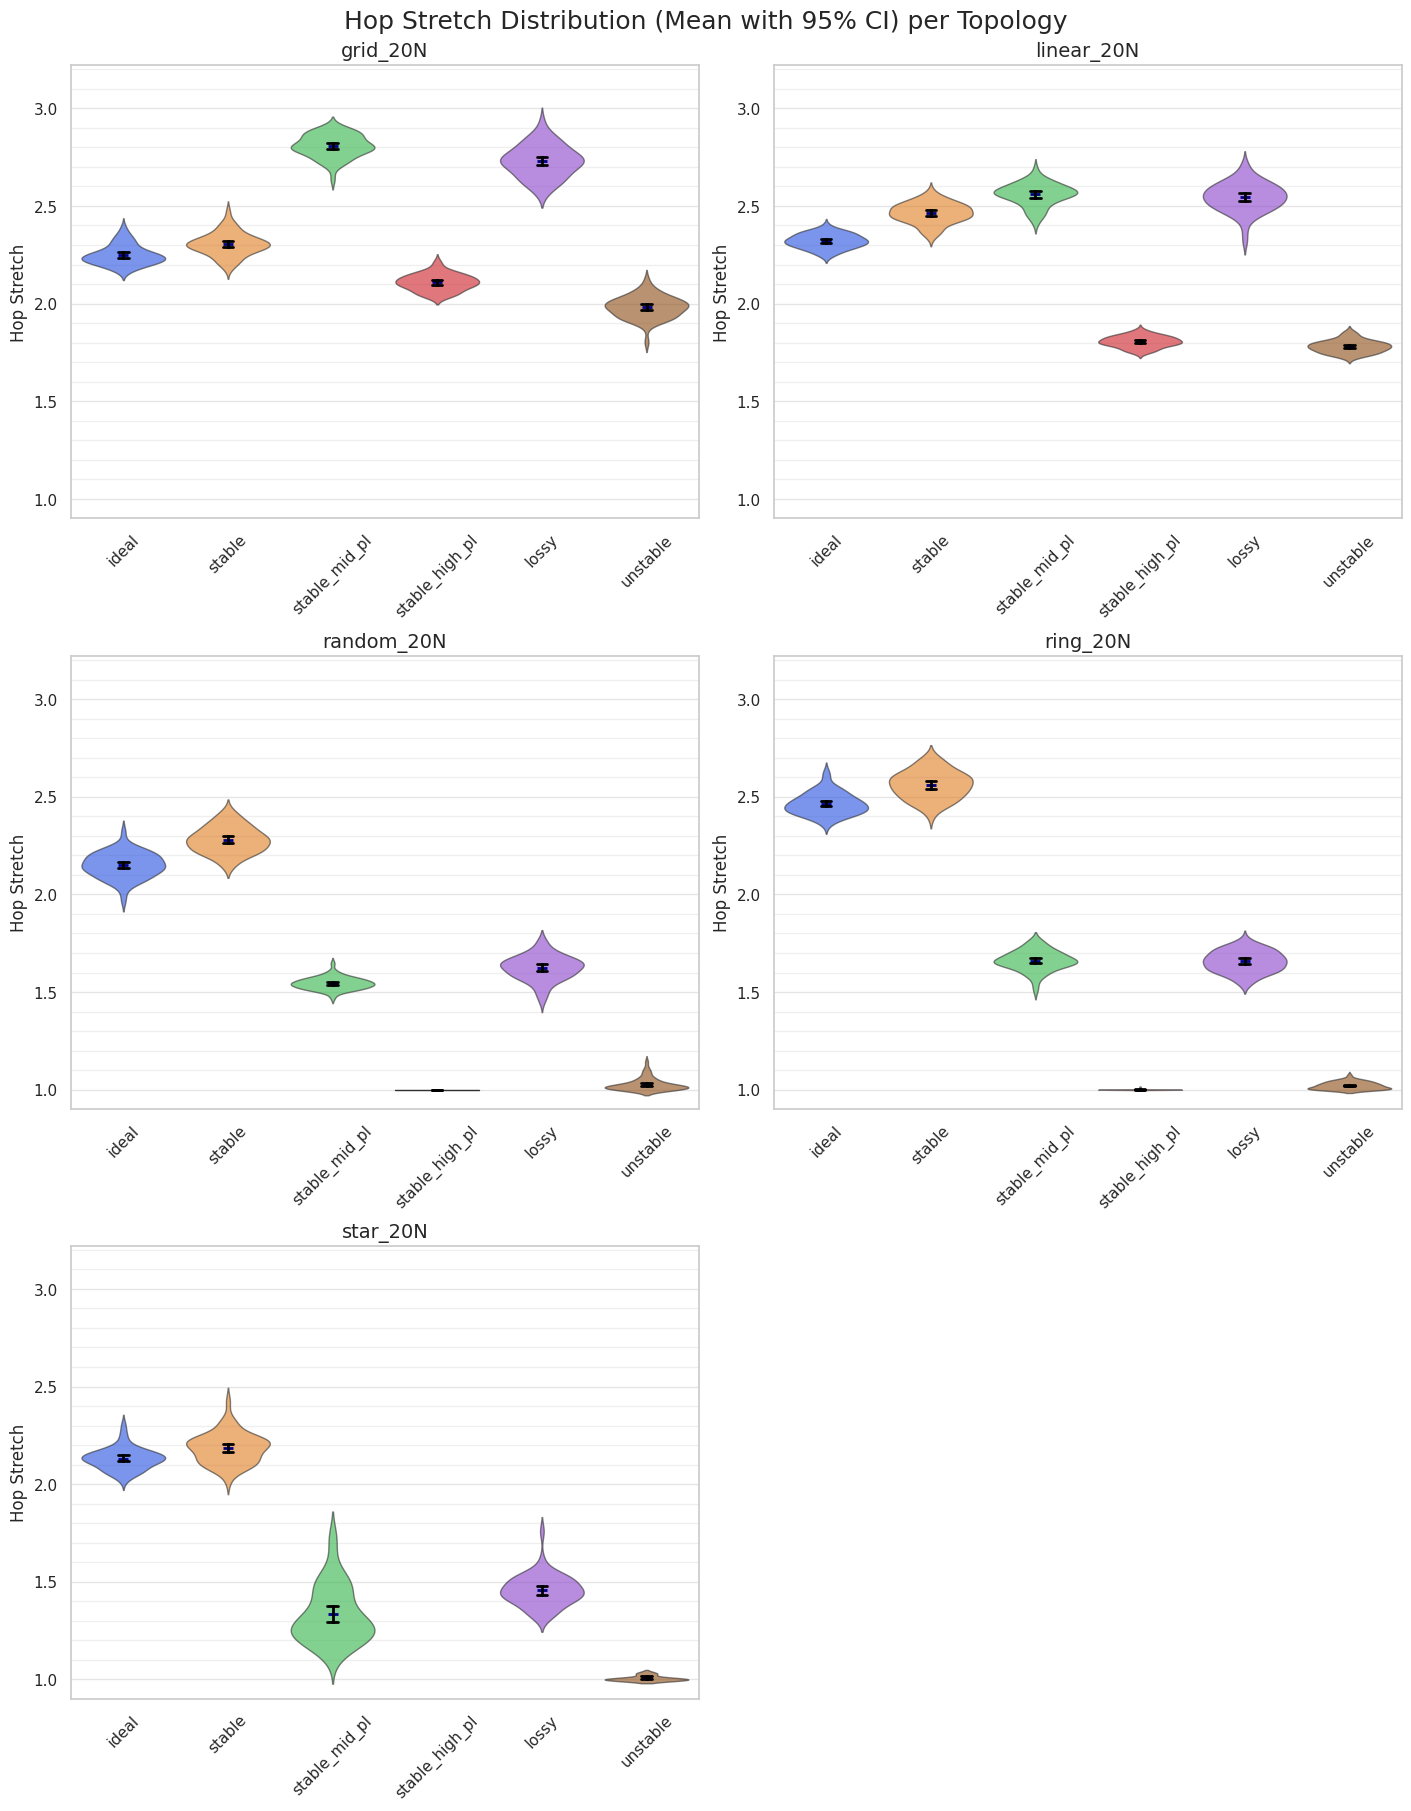

In [68]:
# ==============================================================================
# PLOT HOP STRETCH
# ==============================================================================
plot_violin(
    metric_col="hop_stretch",
    title_prefix="Hop Stretch Distribution",
    ylabel="Hop Stretch",
    ylim=(0.9, all_results_df["hop_stretch"].max() * 1.1),
)